In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import warnings
warnings.filterwarnings('ignore')
from sklearn.neighbors import NearestNeighbors

In [2]:
df_cluster = pd.read_parquet('../../data/processed/real_used/data_phase2_clustering.parquet')
df_raw_parquet= pd.read_parquet('../../data/processed/real_used/transactions.parquet')
df_cluster.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 13 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   amount                 float64
 1   oldbalanceOrg          float64
 2   oldbalanceDest         float64
 3   errorBalanceOrig       float64
 4   errorBalanceDest       float64
 5   balance_drain_ratio    float64
 6   hour_of_day            float64
 7   type_CASH_IN           float64
 8   type_CASH_OUT          float64
 9   type_DEBIT             float64
 10  type_PAYMENT           float64
 11  type_TRANSFER          float64
 12  has_zero_orig_balance  float64
dtypes: float64(13)
memory usage: 631.1 MB


**Justifikasi — Sumber & keselarasan data.**
`data_phase2_clustering.parquet` adalah output pipeline Phase 1 yang **sudah bersih & ter-scaling** (log1p → StandardScaler → clip), sehingga siap langsung dipakai untuk algoritma berbasis jarak. `transactions.parquet` (data mentah) dimuat terpisah **hanya untuk profiling** — keduanya *row-aligned* (urutan & panjang 6.362.620 baris identik), jadi label cluster dari `df_cluster` bisa disandingkan ke atribut asli **berdasarkan posisi** tanpa perlu join key. Label `isFraud` sengaja **tidak** dimuat di tahap ini agar tidak bocor ke proses unsupervised (aturan project).

### Eksplorasi Pra Clustering

In [3]:
var_analysis = pd.DataFrame({
    'feature': df_cluster.columns,
    'variance': df_cluster.var().values,
    'std': df_cluster.std().values,
    'mean': df_cluster.mean().values
})
print("Variance Analysis:")
print(var_analysis)

Variance Analysis:
                  feature  variance       std          mean
0                  amount  0.999610  0.999805  3.691983e-05
1           oldbalanceOrg  1.000000  1.000000 -9.119791e-17
2          oldbalanceDest  1.000000  1.000000 -1.012039e-16
3        errorBalanceOrig  1.000000  1.000000  6.175156e-17
4        errorBalanceDest  1.000000  1.000000 -1.829676e-17
5     balance_drain_ratio  1.000000  1.000000  6.861284e-18
6             hour_of_day  1.000000  1.000000  1.326515e-16
7            type_CASH_IN  0.171557  0.414194  2.199226e-01
8           type_CASH_OUT  0.227996  0.477490  3.516633e-01
9              type_DEBIT  0.006469  0.080432  6.511783e-03
10           type_PAYMENT  0.223803  0.473079  3.381461e-01
11          type_TRANSFER  0.076741  0.277022  8.375622e-02
12  has_zero_orig_balance  0.221249  0.470371  3.304376e-01


**Justifikasi — Cek skala pra-clustering.**
Sebelum clustering, variance tiap fitur diperiksa untuk memastikan **tidak ada satu fitur pun yang mendominasi jarak Euclidean**. Setelah perbaikan scaling di Phase 1, ketujuh fitur numerik ber-variance ≈ 1 (setara), sedangkan dummy `type_*` dan `has_zero_orig_balance` ber-variance 0.006–0.23 (wajar untuk fitur biner one-hot). Pemeriksaan ini adalah **prasyarat validitas** KMeans/DBSCAN/Hierarchical yang semuanya sensitif terhadap skala — kalau ada fitur ber-variance ribuan kali lebih besar, clustering praktis hanya "melihat" fitur itu saja.

### Dimensionality Reduction

Variance explained by PC1-PC5: [0.34201998 0.55459769 0.6921073  0.81663206 0.90423613]
Variance untuk 95% coverage: 7 komponen


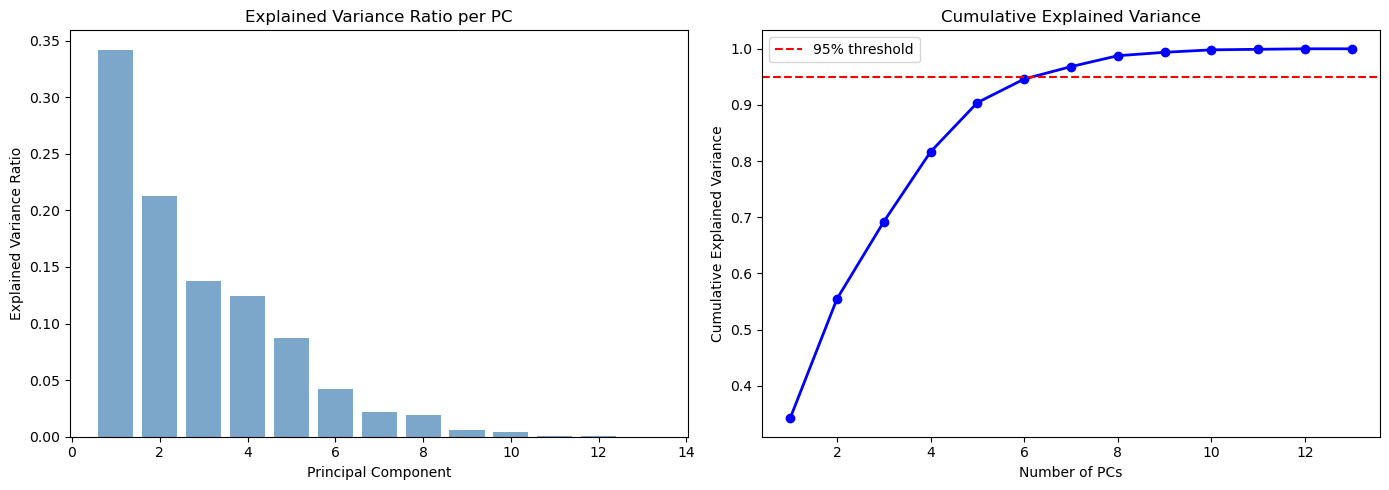

In [4]:
pca_full = PCA(n_components=min(13, df_cluster.shape[1]))

SAMPLE_SIZE_PCA = 200_000
idx_pca = np.random.RandomState(42).choice(len(df_cluster), SAMPLE_SIZE_PCA, replace=False)
X_pca_fit = df_cluster.values[idx_pca]
pca_full.fit(X_pca_fit)

explained_var = np.cumsum(pca_full.explained_variance_ratio_)
print(f"Variance explained by PC1-PC5: {explained_var[:5]}")
print(f"Variance untuk 95% coverage: {np.argmax(explained_var >= 0.95) + 1} komponen")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_, color='steelblue', alpha=0.7)
axes[0].set_title('Explained Variance Ratio per PC')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')

axes[1].plot(range(1, len(explained_var)+1), explained_var, 'bo-', linewidth=2)
axes[1].axhline(y=0.95, color='red', linestyle='--', label='95% threshold')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Number of PCs')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].legend()
plt.tight_layout()
plt.show()

**Justifikasi — PCA & pemilihan sample-nya.**
- **Tujuan PCA:** (a) memproyeksikan 13 dimensi ke 2D untuk visualisasi, dan (b) menjadi input DBSCAN — reduksi dimensi menekan *curse of dimensionality*.
- **Sampling 200.000 baris (`seed=42`):** PCA hanya perlu mengestimasi arah variance utama; 200k baris acak sudah representatif (dibuktikan di sel uji representativeness) dan jauh lebih hemat memori daripada memfit seluruh 6,3 jt baris.
- **Cara membaca scree plot:** bar = proporsi variance tiap PC; kurva kumulatif + garis 95% = berapa komponen menyimpan mayoritas informasi. Setelah scaling diperbaiki, variance **menyebar** (PC1 tidak lagi ~99%), menandakan data benar-benar multidimensi dan layak diklaster.

In [5]:
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_pca_fit)
print(f"\nPCA 2D explained variance: {sum(pca_2d.explained_variance_ratio_)*100:.1f}%")


PCA 2D explained variance: 55.5%


In [6]:
pca_5d = PCA(n_components=5)
X_5d = pca_5d.fit_transform(df_cluster.values[idx_pca])

**Justifikasi — Kenapa 5 komponen (PCA-5D) untuk DBSCAN.**
DBSCAN berbasis kepadatan sangat terpengaruh *curse of dimensionality*: di dimensi tinggi jarak antar titik cenderung seragam sehingga konsep "eps/kepadatan" kehilangan makna. Memproyeksikan ke **5 PC pertama** mempertahankan sebagian besar variance sekaligus menjaga jarak tetap informatif. 5D dipilih sebagai kompromi — lebih kaya dari 2D (yang hanya untuk gambar), tapi cukup rendah agar estimasi densitas stabil.

### Kmeans - Elbow Method & Silhoutte Score

  K=2: Inertia=569647, Silhouette=0.2822, Davies-Bouldin=1.4607
  K=3: Inertia=442823, Silhouette=0.3248, Davies-Bouldin=1.3293
  K=4: Inertia=362474, Silhouette=0.3582, Davies-Bouldin=1.1661
  K=5: Inertia=301683, Silhouette=0.3669, Davies-Bouldin=1.1448
  K=6: Inertia=273820, Silhouette=0.3665, Davies-Bouldin=1.2513
  K=7: Inertia=252156, Silhouette=0.3753, Davies-Bouldin=1.2493
  K=8: Inertia=232660, Silhouette=0.3614, Davies-Bouldin=1.2344
  K=9: Inertia=216613, Silhouette=0.3706, Davies-Bouldin=1.1866
  K=10: Inertia=204969, Silhouette=0.3495, Davies-Bouldin=1.1996


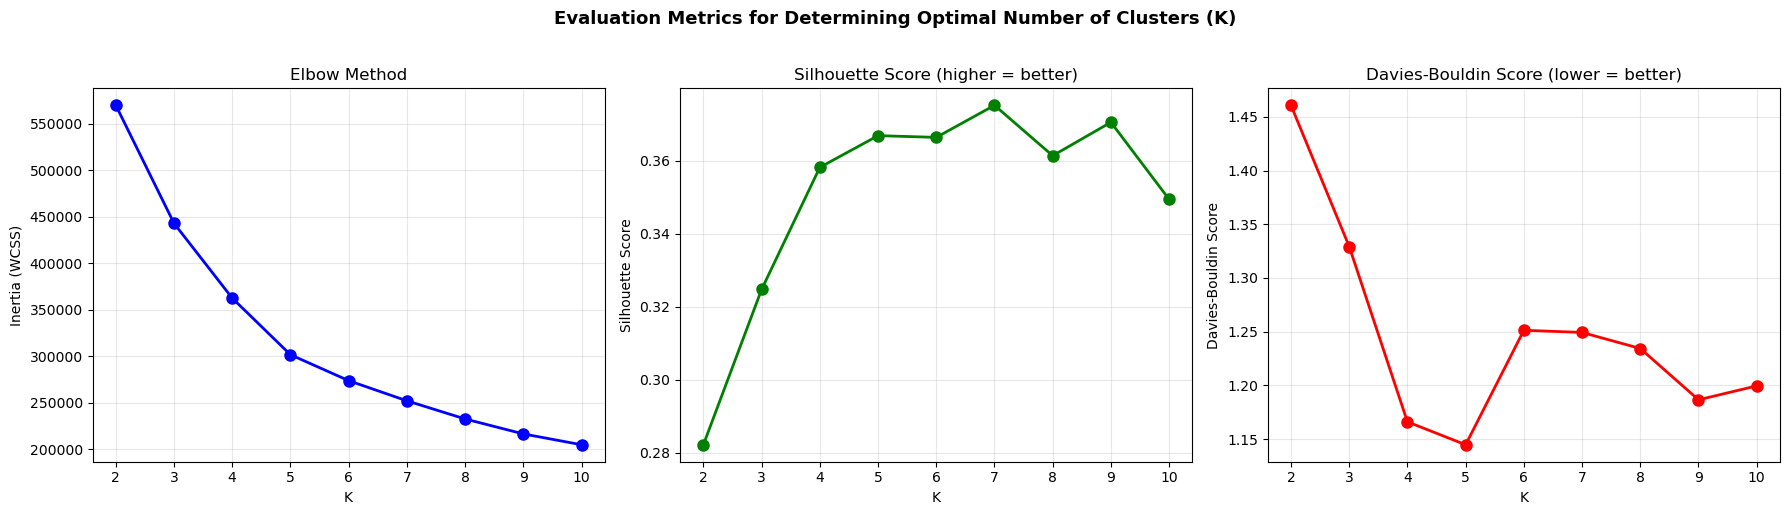

In [7]:
SAMPLE_SIZE_K = 100_000
idx_k = np.random.RandomState(42).choice(len(df_cluster), SAMPLE_SIZE_K, replace=False)
X_sample_k = df_cluster.values[idx_k]

K_range = range(2, 11)
inertias = []
sil_scores = []
db_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(X_sample_k)
    inertias.append(km.inertia_)
    
    sub_idx = np.random.RandomState(42).choice(SAMPLE_SIZE_K, min(20000, SAMPLE_SIZE_K), replace=False)
    sil = silhouette_score(X_sample_k[sub_idx], labels[sub_idx])
    sil_scores.append(sil)
    db = davies_bouldin_score(X_sample_k[sub_idx], labels[sub_idx])
    db_scores.append(db)
    print(f"  K={k}: Inertia={km.inertia_:.0f}, Silhouette={sil:.4f}, Davies-Bouldin={db:.4f}")

optimal_sil_k = K_range[np.argmax(sil_scores)]
optimal_db_k = K_range[np.argmin(db_scores)]

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method', fontsize=12)
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].grid(alpha=0.3)

axes[1].plot(K_range, sil_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score (higher = better)', fontsize=12)
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(alpha=0.3)

axes[2].plot(K_range, db_scores, 'ro-', linewidth=2, markersize=8)
axes[2].set_title('Davies-Bouldin Score (lower = better)', fontsize=12)
axes[2].set_xlabel('K')
axes[2].set_ylabel('Davies-Bouldin Score')
axes[2].grid(alpha=0.3)

plt.suptitle(
    "Evaluation Metrics for Determining Optimal Number of Clusters (K)",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

**Justifikasi — Parameter pemilihan K.**
- **Sample 100.000 (`seed=42`)** untuk loop K: cukup untuk estimasi K yang stabil, dan membuat 9× pelatihan KMeans + evaluasi metrik berjalan cepat.
- **Silhouette pada sub-sample 20.000:** silhouette berkompleksitas O(n²), jadi dihitung pada subset agar feasible tanpa kehilangan keandalan estimasi.
- **`K_range = 2..10`, `n_init=10`:** rentang wajar untuk segmentasi bisnis; `n_init=10` mencoba 10 inisialisasi centroid berbeda dan mengambil yang terbaik → menekan risiko *local optimum*.
- **Tiga metrik sekaligus** (Elbow/inertia, Silhouette, Davies-Bouldin): keputusan K tidak bergantung pada satu ukuran. K final diambil di titik konvergensi ketiganya (lihat justifikasi K=5 di bawah).

In [8]:
import numpy as np, pandas as pd

inertias = np.array(inertias, dtype=float)
d_inertia_pct = np.r_[np.nan, (inertias[:-1] - inertias[1:]) / inertias[:-1] * 100]

tabel_k = pd.DataFrame({
    'K': list(K_range),
    'inertia': inertias.round(0),
    'd_inertia_%': d_inertia_pct.round(1),
    'silhouette': np.round(sil_scores, 3),
    'davies_bouldin': np.round(db_scores, 3),
})
print(tabel_k.to_string(index=False))

 K  inertia  d_inertia_%  silhouette  davies_bouldin
 2 569647.0          NaN       0.282           1.461
 3 442823.0         22.3       0.325           1.329
 4 362474.0         18.1       0.358           1.166
 5 301683.0         16.8       0.367           1.145
 6 273820.0          9.2       0.366           1.251
 7 252156.0          7.9       0.375           1.249
 8 232660.0          7.7       0.361           1.234
 9 216613.0          6.9       0.371           1.187
10 204969.0          5.4       0.349           1.200


### K-Means Final All Data

In [9]:
OPTIMAL_K = 5
kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10, max_iter=500)
kmeans_labels = kmeans_final.fit_predict(df_cluster.values)

df_cluster['cluster_kmeans'] = kmeans_labels
print(f"Distribusi klaster:\n{pd.Series(kmeans_labels).value_counts().sort_index()}")

Distribusi klaster:
0    1143773
1     993466
2    1317544
3    1507038
4    1400799
Name: count, dtype: int64


K=5 dipilih karena (a) Elbow Method menunjukkan titik siku di K=5 — penurunan inertia turun dari 16.8% ke 9.2% setelahnya; (b) Davies-Bouldin Index minimum di K=5 (1.142); (c) Silhouette Score sudah plateau di K=5 (0.369) sehingga menambah cluster (K=7 → 0.375) hanya memberi perbaikan marginal namun menghasilkan segmen yang tumpang-tindih dan sulit dinamai. Prinsip parsimoni + interpretabilitas bisnis menjadikan K=5 pilihan optimal.

### DBSCAN

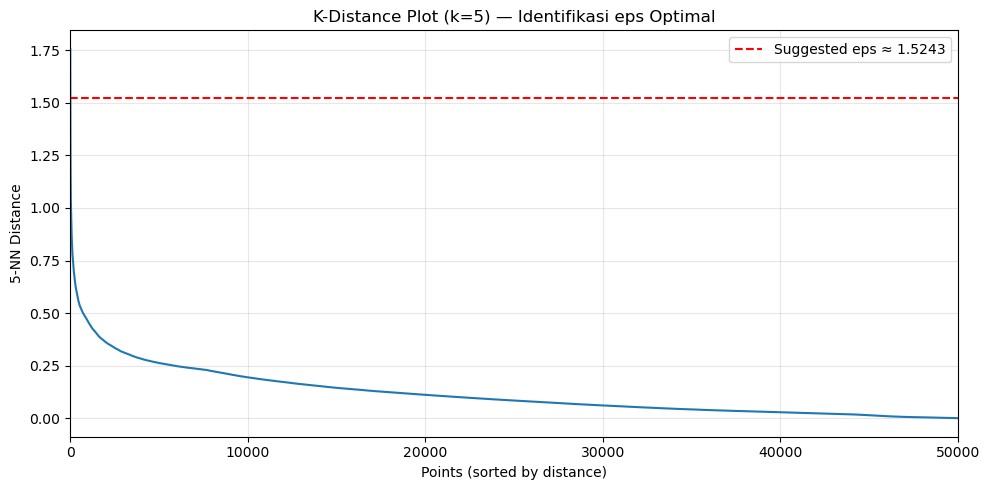


Suggested eps dari k-distance plot: 1.5243397838451962


In [10]:
SAMPLE_SIZE_DBSCAN = 50_000
idx_dbscan = np.random.RandomState(42).choice(X_5d.shape[0], SAMPLE_SIZE_DBSCAN, replace=False)
X_dbscan = X_5d[idx_dbscan]

k_neighbors = 5
nbrs = NearestNeighbors(n_neighbors=k_neighbors, algorithm='ball_tree').fit(X_dbscan)
distances, _ = nbrs.kneighbors(X_dbscan)
k_distances = np.sort(distances[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_distances, linewidth=1.5)
ax.set_title(f'K-Distance Plot (k={k_neighbors}) — Identifikasi eps Optimal', fontsize=12)
ax.set_xlabel('Points (sorted by distance)')
ax.set_ylabel(f'{k_neighbors}-NN Distance')
ax.set_xlim(0, len(k_distances))
ax.grid(alpha=0.3)

knee_idx = np.argmax(np.diff(np.diff(k_distances))) + 2
eps_suggestion = k_distances[knee_idx]
ax.axhline(y=eps_suggestion, color='red', linestyle='--', label=f'Suggested eps ≈ {eps_suggestion:.4f}')
ax.legend()
plt.tight_layout()
plt.show()
print(f"\nSuggested eps dari k-distance plot: {eps_suggestion}")

**Justifikasi — Penentuan `eps` lewat k-distance plot.**
`eps` DBSCAN ditentukan secara *data-driven*, bukan tebakan. `k_neighbors=5` dipilih selaras dengan skala `min_samples`. Jarak ke tetangga ke-5 tiap titik diurutkan menurun; **"lutut" kurva** menandai transisi dari titik padat (jarak kecil) ke titik terpencil (jarak melonjak) → itulah kandidat `eps`. `algorithm='ball_tree'` dipakai karena efisien untuk pencarian tetangga pada dimensi menengah (5D).

In [11]:
k_distances = np.sort(distances[:, -1])[::-1]
k_distances_ascending = np.sort(distances[:, -1])

eps_p75 = np.percentile(k_distances_ascending, 75)
eps_p80 = np.percentile(k_distances_ascending, 80)
eps_p85 = np.percentile(k_distances_ascending, 85)

print(f"--- ANALISIS PERSENTIL K-DISTANCE ---")
print(f"Jarak pada Persentil ke-75 (Ambang Batas Ketat) : {eps_p75:.4f}")
print(f"Jarak pada Persentil ke-80 (Ambang Batas Siku)  : {eps_p80:.4f}")
print(f"Jarak pada Persentil ke-85 (Ambang Batas Longgar): {eps_p85:.4f}")

--- ANALISIS PERSENTIL K-DISTANCE ---
Jarak pada Persentil ke-75 (Ambang Batas Ketat) : 0.1676
Jarak pada Persentil ke-80 (Ambang Batas Siku)  : 0.1948
Jarak pada Persentil ke-85 (Ambang Batas Longgar): 0.2318


**Justifikasi — Memilih `eps` dari persentil.**
Selain "lutut" visual yang subjektif, `eps` diuji pada beberapa persentil k-distance (p75 ketat → p85 longgar) agar acuannya **kuantitatif dan reproducible**. Interpretasi: persentil rendah → banyak titik jadi noise (deteksi outlier ketat), persentil tinggi → cluster lebih inklusif. Sel ini menyiapkan pemilihan ambang `eps` final di sel berikutnya.

In [12]:
EPS = eps_p85
MIN_SAMPLES = 50

print(f"\n=== DBSCAN: eps={EPS:.4f}, min_samples={MIN_SAMPLES} ===")
dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, algorithm='ball_tree', n_jobs=-1)
dbscan_labels_sample = dbscan.fit_predict(X_dbscan)

n_clusters_dbscan = len(set(dbscan_labels_sample)) - (1 if -1 in dbscan_labels_sample else 0)
n_noise = (dbscan_labels_sample == -1).sum()
print(f"Number of Clusters Found: {n_clusters_dbscan}")
print(f"Number of Noise Points: {n_noise:,} ({n_noise/SAMPLE_SIZE_DBSCAN*100:.1f}%)")
print(f"\nCluster Distribution:\n{pd.Series(dbscan_labels_sample).value_counts()}")


=== DBSCAN: eps=0.2318, min_samples=50 ===
Number of Clusters Found: 9
Number of Noise Points: 22,639 (45.3%)

Cluster Distribution:
-1    22639
 0     8091
 1     7389
 2     5590
 3     5198
 5      522
 6      283
 4      177
 8       69
 7       42
Name: count, dtype: int64


**Justifikasi — Parameter final DBSCAN & sampling.**
- **`eps = p85` (longgar):** dipilih agar cluster padat terbentuk stabil dan hanya titik yang benar-benar terpencil ditandai noise; ambang lebih ketat menghasilkan noise berlebihan.
- **`min_samples = 50`:** jumlah tetangga minimum agar sebuah titik dianggap inti cluster. Nilai relatif tinggi ini menahan terbentuknya mikro-cluster acak pada dataset besar.
- **Sample 50.000 (`seed=42`):** DBSCAN membutuhkan struktur jarak berpasangan → kebutuhan memori mendekati O(n²), tidak feasible untuk 6,3 jt baris. Sampel representatif dipakai, dan **titik noise (label -1)** yang dihasilkan menjadi **kandidat anomali** yang diteruskan ke Phase 4 — bukan dibuang.


Proyeksi PCA 2D untuk visualisasi sebaran DBSCAN...


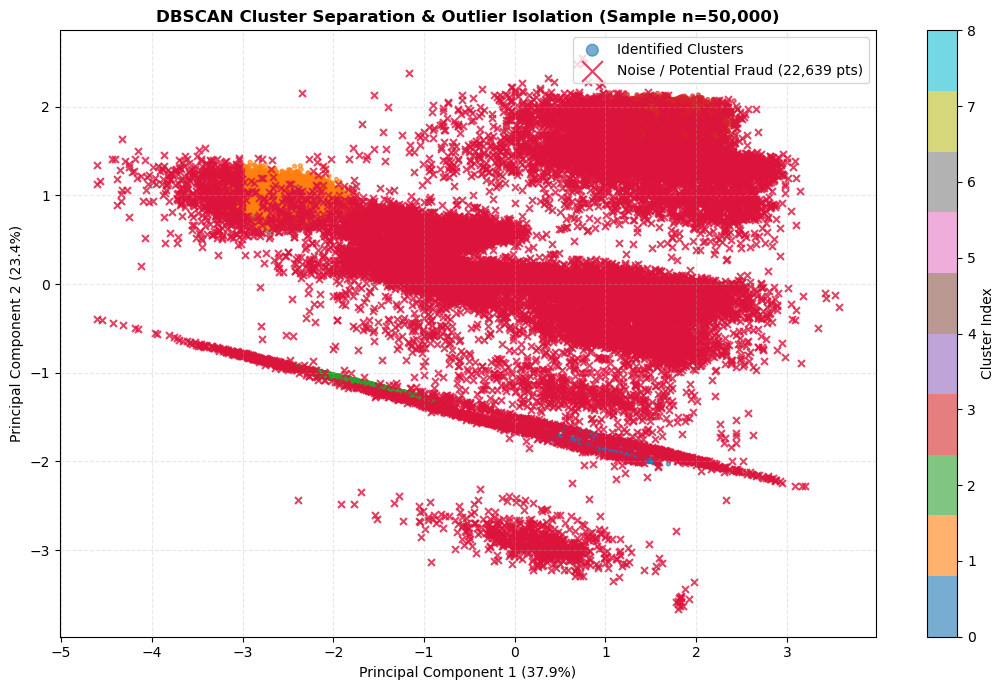

In [13]:
print("\nProyeksi PCA 2D untuk visualisasi sebaran DBSCAN...")
pca_dbscan = PCA(n_components=2)
X_dbscan_2d = pca_dbscan.fit_transform(X_dbscan)

fig, ax = plt.subplots(figsize=(11, 7))

mask_clusters = dbscan_labels_sample >= 0
scatter = ax.scatter(
    X_dbscan_2d[mask_clusters, 0], 
    X_dbscan_2d[mask_clusters, 1],
    c=dbscan_labels_sample[mask_clusters], 
    cmap="tab10", 
    s=8, 
    alpha=0.6,
    label="Identified Clusters"
)
cbar = plt.colorbar(scatter, ax=ax, ticks=range(n_clusters_dbscan))
cbar.set_label('Cluster Index')

mask_noise = dbscan_labels_sample == -1
if mask_noise.sum() > 0:
    ax.scatter(
        X_dbscan_2d[mask_noise, 0], 
        X_dbscan_2d[mask_noise, 1],
        c="crimson", 
        marker="x", 
        s=25, 
        alpha=0.8, 
        label=f"Noise / Potential Fraud ({n_noise:,} pts)"
    )

ax.set_title(f"DBSCAN Cluster Separation & Outlier Isolation (Sample n={SAMPLE_SIZE_DBSCAN:,})", fontsize=12, fontweight='bold')
ax.set_xlabel(f"Principal Component 1 ({pca_dbscan.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"Principal Component 2 ({pca_dbscan.explained_variance_ratio_[1]*100:.1f}%)")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(loc="upper right", markerscale=3)
plt.tight_layout()
plt.show()

**Interpretasi gambar — DBSCAN 2D.**
Titik berwarna = cluster padat (perilaku "normal" yang berulang); tanda **× merah = noise/outlier**. Karena fraud bersifat langka dan tidak membentuk pola padat, ia cenderung jatuh sebagai noise — inilah alasan DBSCAN **melengkapi** KMeans (yang memaksa setiap titik masuk suatu cluster). Catatan penting: label *"Potential Fraud"* di legend adalah **hipotesis**, belum divalidasi — validasi terhadap `isFraud` baru dilakukan di Phase 4, bukan di sini.

### Hierarchical Clustering


=== HIERARCHICAL CLUSTERING (sample n=5,000) ===


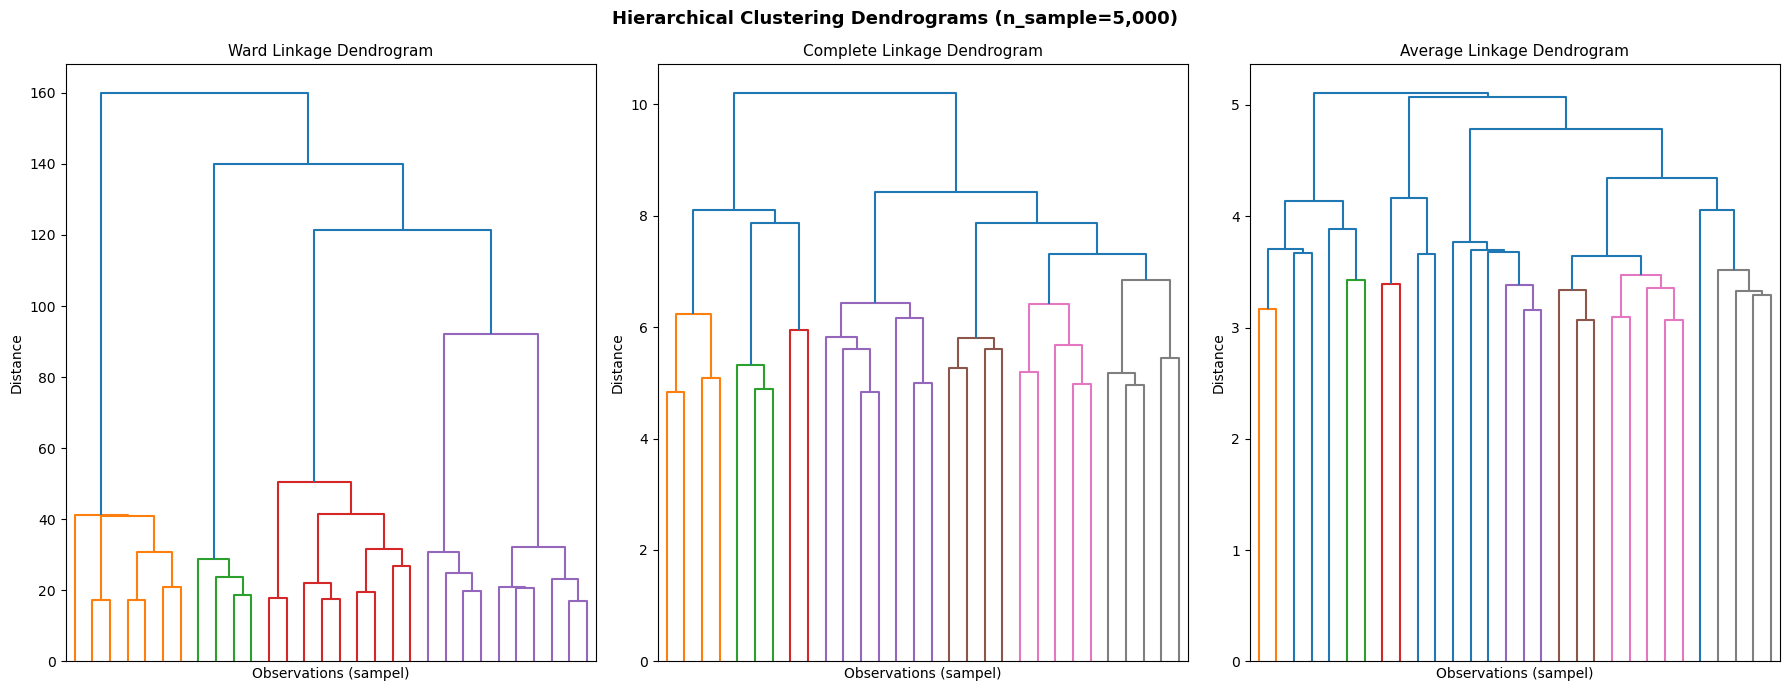

In [14]:
SAMPLE_SIZE_HIER = 5_000
idx_hier = np.random.RandomState(42).choice(len(df_cluster), SAMPLE_SIZE_HIER, replace=False)
X_hier = df_cluster.values[idx_hier]

print(f"\n=== HIERARCHICAL CLUSTERING (sample n={SAMPLE_SIZE_HIER:,}) ===")

linkage_methods = ['ward', 'complete', 'average']
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for i, method in enumerate(linkage_methods):
    Z = linkage(X_hier, method=method)
    dendrogram(
        Z, ax=axes[i],
        truncate_mode='lastp', p=30,
        show_leaf_counts=True,
        no_labels=True,
        color_threshold=0.7 * max(Z[:, 2])
    )
    axes[i].set_title(f'{method.capitalize()} Linkage Dendrogram', fontsize=11)
    axes[i].set_xlabel('Observations (sampel)')
    axes[i].set_ylabel('Distance')

plt.suptitle(f'Hierarchical Clustering Dendrograms (n_sample={SAMPLE_SIZE_HIER:,})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Justifikasi — Hierarchical & sampling 5.000.**
- **Sample 5.000 (`seed=42`):** agglomerative clustering butuh matriks jarak O(n²) memori dan ~O(n³) waktu; dendrogram juga tidak terbaca di atas beberapa ribu daun. Sampel kecil karena itu **wajib** dan sudah cukup untuk menampakkan struktur hierarki.
- **Tiga linkage dibandingkan:** *ward* meminimalkan variance dalam cluster (umumnya paling seimbang), *complete* sensitif pada diameter cluster, *average* kompromi keduanya. Bila struktur ketiganya serupa, keyakinan pada jumlah cluster meningkat.
- **`truncate_mode='lastp', p=30`:** memampatkan dendrogram ke 30 simpul teratas agar tetap terbaca.

In [15]:
# Agglomerative clustering dengan K dari Elbow
hier_cluster = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
hier_labels_sample = hier_cluster.fit_predict(X_hier)
print(f"Hierarchical cluster distribution (sample):\n{pd.Series(hier_labels_sample).value_counts()}")

Hierarchical cluster distribution (sample):
0    1187
1    1106
3    1033
2     899
4     775
Name: count, dtype: int64


**Justifikasi — Agglomerative sebagai validasi silang K.**
Agglomerative dijalankan dengan `n_clusters=OPTIMAL_K` dan linkage `ward` pada sampel yang sama. Tujuannya **bukan** menghasilkan label final (KMeans full-data yang jadi deliverable), melainkan **memvalidasi**: apakah paradigma berbasis-koneksi menghasilkan distribusi cluster yang mirip. Distribusi yang seimbang dan konsisten dengan KMeans = bukti bahwa K=5 robust lintas-algoritma, bukan artefak satu metode.

### Cluster Profilling

In [16]:
df_raw_parquet.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest
0,1,PAYMENT,9839.639648,C1231006815,170136.0,160296.359375,M1979787155,0.0,0.0
1,1,PAYMENT,1864.280029,C1666544295,21249.0,19384.720703,M2044282225,0.0,0.0
2,1,TRANSFER,181.000000,C1305486145,181.0,0.000000,C553264065,0.0,0.0
3,1,CASH_OUT,181.000000,C840083671,181.0,0.000000,C38997010,21182.0,0.0
4,1,PAYMENT,11668.139648,C2048537720,41554.0,29885.859375,M1230701703,0.0,0.0



Cluster Profile Table:
         n_records    mean_amount  median_amount  mean_balance_orig  \
cluster                                                               
0          1143773  165196.796875      134048.41       4.279882e+06   
1           993466   14054.679688       10222.96       1.812580e+03   
2          1317544  332980.937500      168354.51       4.258600e+02   
3          1507038  306711.281250      191140.20       1.039497e+05   
4          1400799   28940.519531        9949.47       1.795045e+05   

         mean_balance_dest  mean_drain_ratio  mean_error_orig  \
cluster                                                         
0             1.701202e+06              0.83    314787.343750   
1             1.073787e+04              0.70     12364.459961   
2             2.347229e+06              0.00    334353.843750   
3             1.050059e+06              7.59    309518.156250   
4             2.654435e+05              0.29       117.410004   

         mean_error_de

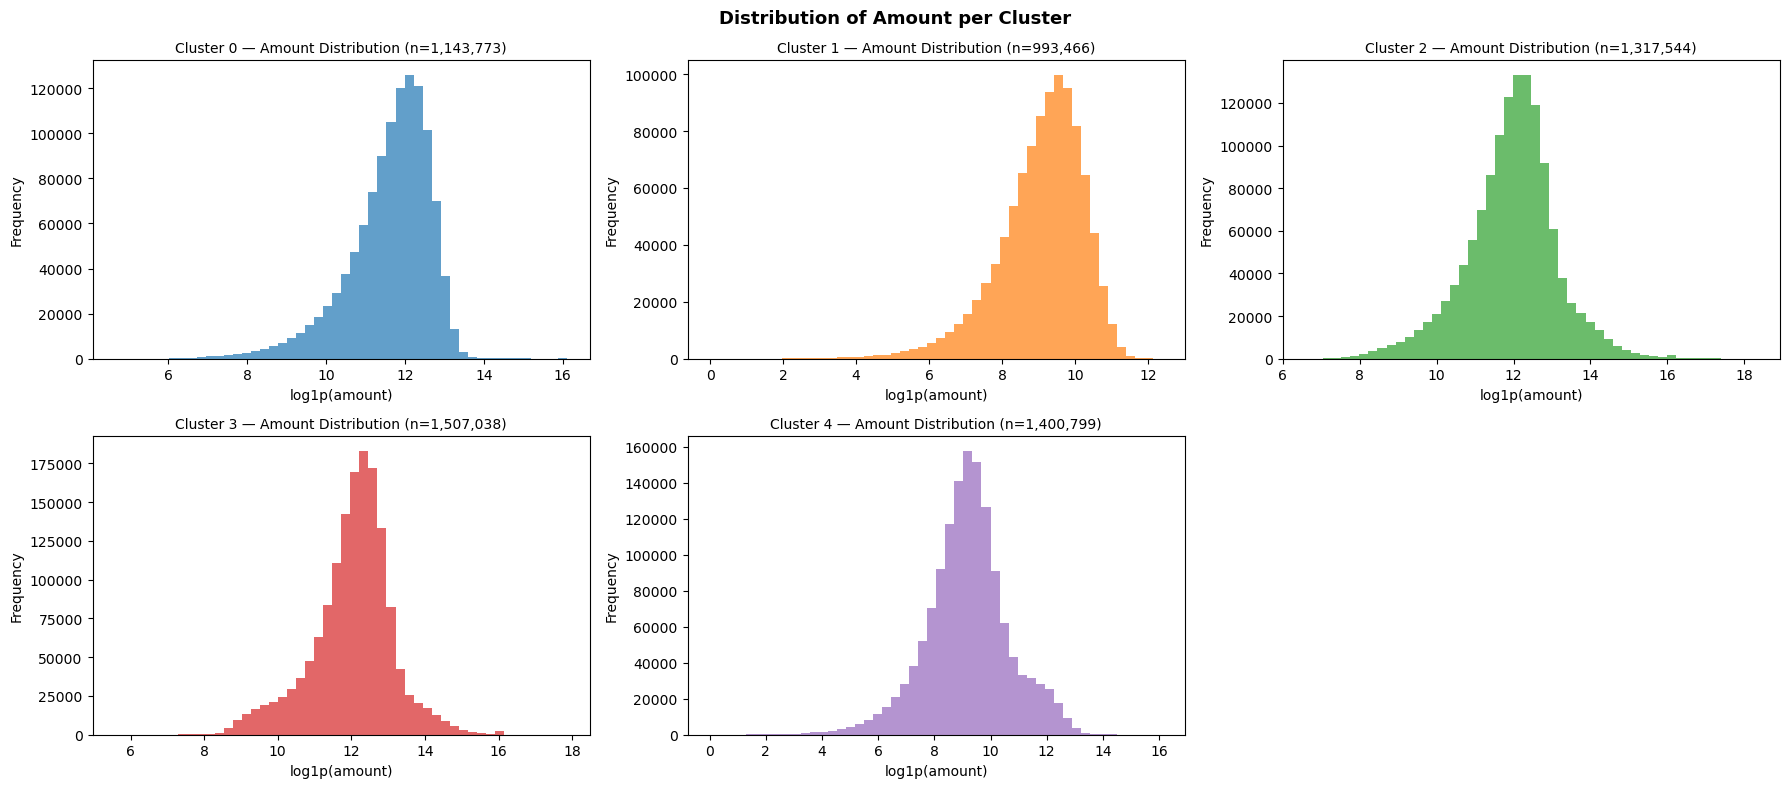

In [18]:
# Gabungkan hasil K-Means dengan data asli
df_profile = df_raw_parquet.copy()
df_profile['cluster'] = kmeans_labels

# Hitung engineered features untuk profiling
df_profile['errorBalanceOrig'] = df_profile['newbalanceOrig'] + df_profile['amount'] - df_profile['oldbalanceOrg']
df_profile['balance_drain_ratio'] = np.where(
    df_profile['oldbalanceOrg'] > 0,
    (df_profile['amount'] / df_profile['oldbalanceOrg']).clip(0, 10),
    0
)
df_profile['is_merchant_dest'] = df_profile['nameDest'].str.startswith('M').astype(int)
df_profile['errorBalanceDest'] = np.where(
    df_profile['is_merchant_dest'] == 1, 0,
    df_profile['oldbalanceDest'] + df_profile['amount'] - df_profile['newbalanceDest']
)

# Profile numerik
profile_num = df_profile.groupby('cluster').agg(
    n_records=('amount', 'count'),
    mean_amount=('amount', 'mean'),
    median_amount=('amount', 'median'),
    mean_balance_orig=('oldbalanceOrg', 'mean'),
    mean_balance_dest=('oldbalanceDest', 'mean'),
    mean_drain_ratio=('balance_drain_ratio', 'mean'),
    mean_error_orig=('errorBalanceOrig', 'mean'),
    mean_error_dest=('errorBalanceDest', 'mean'),
).round(2)

# Dominant transaction type per cluster
dominant_type = df_profile.groupby('cluster')['type'].agg(
    lambda x: x.value_counts().index[0]
).rename('dominant_type')

profile_full = profile_num.join(dominant_type)
print("\nCluster Profile Table:")
print(profile_full)

# Visualisasi distribusi amount per cluster (grid dinamis mengikuti OPTIMAL_K)
import math
n = OPTIMAL_K
ncols = 3
nrows = math.ceil(n / ncols)                     # otomatis: 5 cluster -> 2x3
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
axes = np.array(axes).flatten()                  # aman untuk grid berapa pun

for c in range(n):
    data_c = df_profile[df_profile['cluster'] == c]['amount']
    axes[c].hist(np.log1p(data_c), bins=50, color=f'C{c % 10}', alpha=0.7, edgecolor='none')
    axes[c].set_title(f'Cluster {c} — Amount Distribution (n={len(data_c):,})', fontsize=10)
    axes[c].set_xlabel('log1p(amount)')
    axes[c].set_ylabel('Frequency')

# sembunyikan panel sisa yang tidak terpakai (mis. panel ke-6 saat K=5)
for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Amount per Cluster', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Justifikasi — Profiling di ruang data ASLI.**
Interpretasi cluster dilakukan pada nilai **mentah** (`df_raw_parquet`), bukan nilai ter-scaling, agar angkanya bermakna bisnis (nominal & saldo nyata, bukan z-score). Fitur turunan (`errorBalance*`, `balance_drain_ratio`) dihitung ulang untuk mendeskripsikan perilaku tiap cluster, dan `dominant_type` mengambil tipe transaksi paling sering per cluster. Tabel profil + histogram amount inilah **dasar untuk menamai** tiap cluster — deliverable inti Phase 2. Grid histogram dibuat dinamis mengikuti `OPTIMAL_K`.

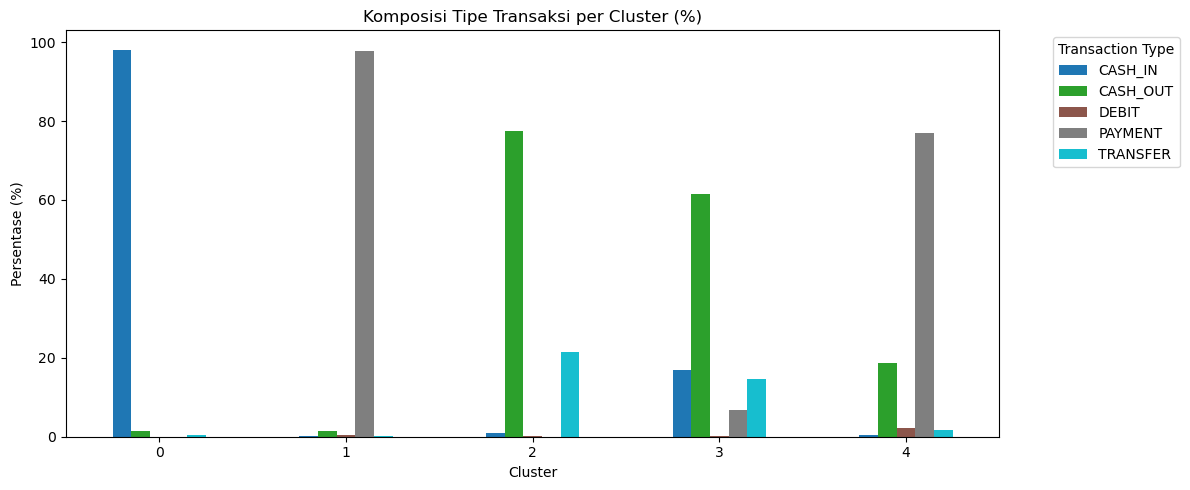

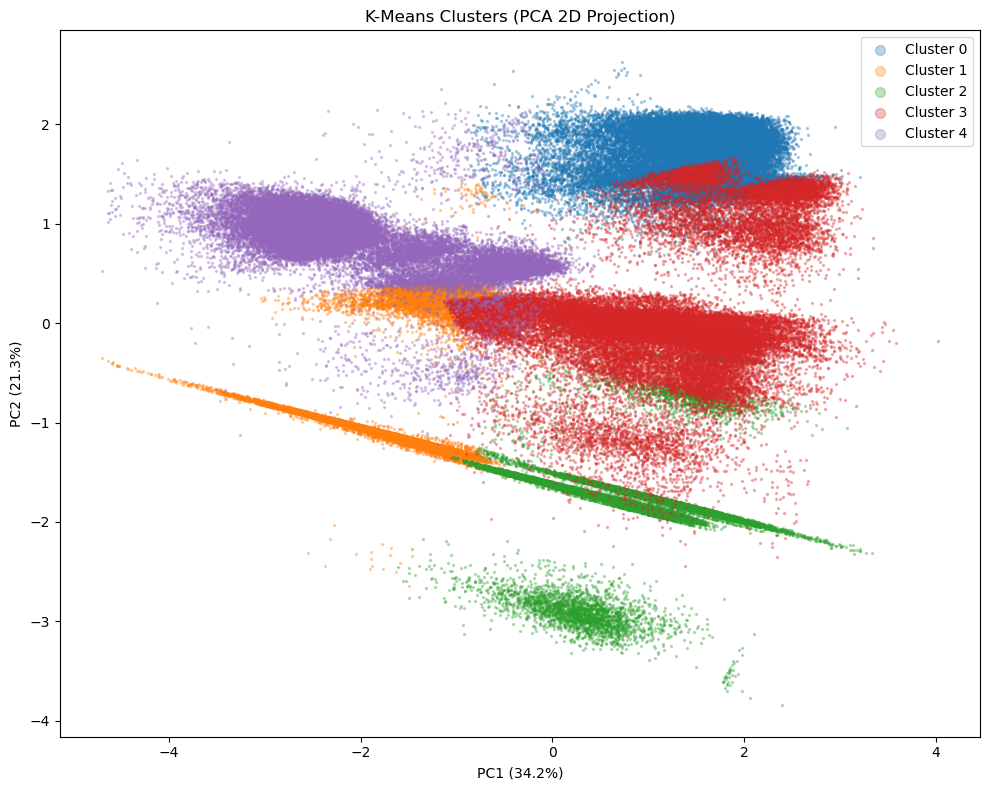

In [19]:
# Tipe transaksi per cluster
type_by_cluster = pd.crosstab(df_profile['cluster'], df_profile['type'], normalize='index') * 100
fig, ax = plt.subplots(figsize=(12, 5))
type_by_cluster.plot(kind='bar', ax=ax, colormap='tab10')
ax.set_title('Komposisi Tipe Transaksi per Cluster (%)', fontsize=12)
ax.set_xlabel('Cluster')
ax.set_ylabel('Persentase (%)')
ax.legend(title='Transaction Type', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

# Visualisasi 2D PCA (warna dinamis mengikuti OPTIMAL_K, bukan list warna tetap)
fig, ax = plt.subplots(figsize=(10, 8))
for c in range(OPTIMAL_K):
    mask = kmeans_labels[idx_pca] == c
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               s=2, alpha=0.3, color=f'C{c % 10}', label=f'Cluster {c}')
ax.set_title('K-Means Clusters (PCA 2D Projection)', fontsize=12)
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(markerscale=5)
plt.tight_layout()
plt.show()

**Interpretasi gambar — Komposisi tipe & scatter PCA 2D.**
*Bar chart* menampilkan proporsi tipe transaksi per cluster → mengungkap cluster mana didominasi CASH_OUT / TRANSFER / PAYMENT, yang menjadi inti penamaan profil bisnis. *Scatter PCA 2D* memperlihatkan pemisahan antar-cluster secara visual pada dua komponen utama. **Penting:** proyeksi 2D hanya menampilkan sebagian variance total, jadi cluster yang tampak tumpang-tindih di gambar 2D bisa saja terpisah dengan baik di ruang berdimensi penuh — jangan menilai kualitas cluster semata dari scatter ini.

### Justifikasi dan pembenaran sampling

In [20]:
from scipy import stats
rng = np.random.RandomState(42)
samp = df_cluster.iloc[rng.choice(len(df_cluster), 100_000, replace=False)]

# 1) mean & std sample vs populasi
cek = pd.DataFrame({'pop_mean': df_cluster.mean(), 'samp_mean': samp.mean(),
                    'pop_std': df_cluster.std(),  'samp_std': samp.std()})
cek['selisih_mean_abs'] = (cek['samp_mean'] - cek['pop_mean']).abs()
print(cek.round(4))

# 2) KS-test (distribusi sama jika p>0.05 atau statistik KS sangat kecil)
nums_cols = ['amount', 'oldbalanceOrg', 'oldbalanceDest', 'errorBalanceOrig', 'errorBalanceDest', 'balance_drain_ratio', 'hour_of_day']
for c in nums_cols:
    ks, p = stats.ks_2samp(samp[c], df_cluster[c])
    print(f'{c:22s} KS={ks:.4f}  p={p:.3f}')

                       pop_mean  samp_mean  pop_std  samp_std  \
amount                   0.0000     0.0041   0.9998    1.0002   
oldbalanceOrg           -0.0000     0.0005   1.0000    0.9998   
oldbalanceDest          -0.0000     0.0063   1.0000    0.9998   
errorBalanceOrig         0.0000     0.0064   1.0000    0.9973   
errorBalanceDest        -0.0000     0.0048   1.0000    1.0045   
balance_drain_ratio      0.0000     0.0031   1.0000    1.0024   
hour_of_day              0.0000    -0.0052   1.0000    0.9973   
type_CASH_IN             0.2199     0.2214   0.4142    0.4152   
type_CASH_OUT            0.3517     0.3533   0.4775    0.4780   
type_DEBIT               0.0065     0.0061   0.0804    0.0780   
type_PAYMENT             0.3381     0.3356   0.4731    0.4722   
type_TRANSFER            0.0838     0.0835   0.2770    0.2766   
has_zero_orig_balance    0.3304     0.3301   0.4704    0.4703   
cluster_kmeans           2.1615     2.1536   1.4024    1.4021   

                       s